<a href="https://colab.research.google.com/github/samarranjit/Yield_Prediction/blob/main/Deep_Learning_Techniques/Attention_based_LSTM_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attention Based LSTM Model

### This notebook will train and test a LSTM Model that utilizes attention to see how the performance compares to the CNN LSTM model

We aim to see how effective CNN model is in the CNN LSTM model


## Importing all the required libraries

In [132]:
import os, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
import seaborn as sns

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

plt.rcParams["figure.dpi"] = 120


Device: cuda
GPU: Quadro RTX 8000


## Importing the dataset

In [133]:
# corn_fn = r"/content/drive/MyDrive/Colab Notebooks/Data For Yield Prediction/30mdatasets/Recalculated/2corn_monthly_timeseries_imputed_recalculated.parquet"
# wheat_fn = r"/content/drive/MyDrive/Colab Notebooks/Data For Yield Prediction/30mdatasets/Recalculated/2wheat_monthly_timeseries_imputed_recalculated.parquet"
# soy_fn = r"/content/drive/MyDrive/Colab Notebooks/Data For Yield Prediction/30mdatasets/Recalculated/2soybeans_monthly_timeseries_imputed_recalculated.parquet"
corn_fn = r"/home/cholab/LabMembers/Samar/Yield_Prediction/data/monthlyTimeseriesData/2corn_monthly_timeseries_imputed_recalculated.parquet"
wheat_fn = r"/home/cholab/LabMembers/Samar/Yield_Prediction/data/monthlyTimeseriesData/2wheat_monthly_timeseries_imputed_recalculated.parquet"
soy_fn = r"/home/cholab/LabMembers/Samar/Yield_Prediction/data/monthlyTimeseriesData/2soybeans_monthly_timeseries_imputed_recalculated.parquet"
CROP = "soy"   # "soy" | "corn" | "wheat"

fn_map = {"soy": soy_fn, "corn": corn_fn, "wheat": wheat_fn}
data_path = fn_map[CROP]

df = pd.read_parquet(data_path)
print("Loaded:", data_path)
print("Shape:", df.shape)
df.head()


Loaded: /home/cholab/LabMembers/Samar/Yield_Prediction/data/monthlyTimeseriesData/2soybeans_monthly_timeseries_imputed_recalculated.parquet
Shape: (241080, 69)


,field,year,row,col,yield_mean,yield_std,yield_count,lon,lat,grid_crs,...,GI,NDWI,Tr_SWIR1,Tr_SWIR2,LST_K,PPT_mm,PPT_obsCount,HLS_obsCount,LST_obsCount,window
0,South Farm_SA-5,2019,126,30,22.214909,NaN,1,-76.953236,39.011901,EPSG:4326,...,2.811321,-0.049308,0.764619,1.647770,298.015411,47.394001,30.0,11.0,2.0,None
1,South Farm_SA-5,2019,126,30,22.214909,NaN,1,-76.953236,39.011901,EPSG:4326,...,4.803632,0.259259,1.349838,3.625084,303.579956,153.701004,31.0,13.0,2.0,None
2,South Farm_SA-5,2019,126,30,22.214909,NaN,1,-76.953236,39.011901,EPSG:4326,...,3.167556,-0.015197,0.777377,1.803697,304.977921,67.210999,30.0,12.0,2.0,None
3,South Farm_SA-5,2019,126,30,22.214909,NaN,1,-76.953236,39.011901,EPSG:4326,...,3.740914,0.031624,0.864254,2.350744,306.375885,113.481995,31.0,11.0,2.0,None
4,South Farm_SA-5,2019,126,30,22.214909,NaN,1,-76.953236,39.011901,EPSG:4326,...,4.297053,0.107294,0.969293,2.538330,308.248962,94.362000,31.0,13.0,2.0,None


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241080 entries, 0 to 241079
Data columns (total 69 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   field            241080 non-null  object 
 1   year             241080 non-null  int64  
 2   row              241080 non-null  int64  
 3   col              241080 non-null  int64  
 4   yield_mean       241080 non-null  float64
 5   yield_std        234720 non-null  float64
 6   yield_count      241080 non-null  int64  
 7   lon              241080 non-null  float64
 8   lat              241080 non-null  float64
 9   grid_crs         241080 non-null  object 
 10  template_raster  241080 non-null  object 
 11  yield_meter_crs  241080 non-null  object 
 12  LST_median       241080 non-null  float64
 13  LST_max          241080 non-null  float64
 14  LST_range        241080 non-null  float64
 15  NDVI_mean        241080 non-null  float64
 16  EVI_mean         241080 non-null  floa

In [134]:
df.rename(columns={"x_utm": "x_m", "y_utm": "y_m"}, inplace=True)
df.head()

,field,year,row,col,yield_mean,yield_std,yield_count,lon,lat,grid_crs,...,GI,NDWI,Tr_SWIR1,Tr_SWIR2,LST_K,PPT_mm,PPT_obsCount,HLS_obsCount,LST_obsCount,window
0,South Farm_SA-5,2019,126,30,22.214909,NaN,1,-76.953236,39.011901,EPSG:4326,...,2.811321,-0.049308,0.764619,1.647770,298.015411,47.394001,30.0,11.0,2.0,None
1,South Farm_SA-5,2019,126,30,22.214909,NaN,1,-76.953236,39.011901,EPSG:4326,...,4.803632,0.259259,1.349838,3.625084,303.579956,153.701004,31.0,13.0,2.0,None
2,South Farm_SA-5,2019,126,30,22.214909,NaN,1,-76.953236,39.011901,EPSG:4326,...,3.167556,-0.015197,0.777377,1.803697,304.977921,67.210999,30.0,12.0,2.0,None
3,South Farm_SA-5,2019,126,30,22.214909,NaN,1,-76.953236,39.011901,EPSG:4326,...,3.740914,0.031624,0.864254,2.350744,306.375885,113.481995,31.0,11.0,2.0,None
4,South Farm_SA-5,2019,126,30,22.214909,NaN,1,-76.953236,39.011901,EPSG:4326,...,4.297053,0.107294,0.969293,2.538330,308.248962,94.362000,31.0,13.0,2.0,None


In [135]:
df = df.drop(columns=[ 'Soil_Sand', 'Soil_Silt', 'Soil_Theta_R',  'Soil_Lambda', 'Soil_Alpha', 'Soil_N'])

In [71]:
df.keys()

Index(['field', 'year', 'row', 'col', 'yield_mean', 'yield_std', 'yield_count',
       'lon', 'lat', 'grid_crs', 'template_raster', 'yield_meter_crs',
       'LST_median', 'LST_max', 'LST_range', 'NDVI_mean', 'EVI_mean',
       'GI_mean', 'NDWI_mean', 'Tr_SWIR1_mean', 'Tr_SWIR2_mean', 'NDVI_max',
       'EVI_max', 'GI_max', 'NDWI_max', 'Tr_SWIR1_max', 'Tr_SWIR2_max',
       'NDVI_range', 'EVI_range', 'GI_range', 'NDWI_range', 'Tr_SWIR1_range',
       'Tr_SWIR2_range', 'NDVI_obsCount', 'ppt_mean', 'ppt_max', 'ppt_range',
       'ppt_total', 'Soil_Clay', 'Soil_BD', 'Soil_pH', 'Soil_OM',
       'Soil_Theta_S', 'Soil_Ksat', 'x_m', 'y_m', 'elevation', 'slope',
       'aspect', 'month', 'month_index', 'NDVI', 'EVI', 'GI', 'NDWI',
       'Tr_SWIR1', 'Tr_SWIR2', 'LST_K', 'PPT_mm', 'PPT_obsCount',
       'HLS_obsCount', 'LST_obsCount', 'window'],
      dtype='object')

### Building sequences


In [136]:

# 2) Column definitions
SEASON_MONTHS = list(range(4, 12))  # Apr(4) ... Nov(11), T=8

key_cols = ['field', 'year', 'row', 'col']
t_col = 'month'
target_col = 'yield_mean'

# Dynamic monthly features (per timestep)
ts_cols = ['NDVI','EVI','GI','NDWI','Tr_SWIR1','Tr_SWIR2','LST_K','PPT_mm']
qc_cols = ['HLS_obsCount','LST_obsCount','PPT_obsCount']
dyn_cols = ts_cols + qc_cols

# Static features (same for each pixel-year)
soil_cols = [c for c in df.columns if c.startswith("Soil_")]
topo_cols = ['elevation','slope','aspect']
summary_cols = [
    'LST_median','LST_max','LST_range',
    'NDVI_mean','EVI_mean','GI_mean','NDWI_mean','Tr_SWIR1_mean','Tr_SWIR2_mean',
    'NDVI_max','EVI_max','GI_max','NDWI_max','Tr_SWIR1_max','Tr_SWIR2_max',
    'NDVI_range','EVI_range','GI_range','NDWI_range','Tr_SWIR1_range','Tr_SWIR2_range',
    'ppt_mean','ppt_max','ppt_range','ppt_total'
]
static_cols = soil_cols + topo_cols + summary_cols

print("dyn_cols:", len(dyn_cols))
print("static_cols:", len(static_cols), "| soil:", len(soil_cols))

missing = [c for c in key_cols + [t_col, target_col] + dyn_cols + static_cols if c not in df.columns]
if missing:
    print("WARNING: missing columns:", missing)


dyn_cols: 11
static_cols: 34 | soil: 6


In [137]:

# 3) Season filter + cleaning
df_season = df[df[t_col].isin(SEASON_MONTHS)].copy()
df_season = df_season.dropna(subset=key_cols + [t_col])

# Keep rows even if some dyn values are NaN (masking handles it)
df_season = df_season.dropna(subset=dyn_cols, how="all")

# Make sure types are consistent
df_season['year'] = df_season['year'].astype(int)
df_season['row'] = df_season['row'].astype(int)
df_season['col'] = df_season['col'].astype(int)
df_season[t_col] = df_season[t_col].astype(int)

df_season = df_season.sort_values(key_cols + [t_col])
print("df_season:", df_season.shape)
display(df_season.head())


df_season: (241080, 63)


,field,year,row,col,yield_mean,yield_std,yield_count,lon,lat,grid_crs,...,GI,NDWI,Tr_SWIR1,Tr_SWIR2,LST_K,PPT_mm,PPT_obsCount,HLS_obsCount,LST_obsCount,window
58344,APU_1,2016,110,250,22.289373,1.727509,13,-76.893947,39.016213,EPSG:4326,...,5.089419,0.246805,1.526805,3.850564,291.924500,52.487000,30.0,6.0,1.0,None
58345,APU_1,2016,110,250,22.289373,1.727509,13,-76.893947,39.016213,EPSG:4326,...,4.324948,0.148996,1.112515,2.812059,297.340363,149.804993,31.0,4.0,2.0,None
58346,APU_1,2016,110,250,22.289373,1.727509,13,-76.893947,39.016213,EPSG:4326,...,3.560477,0.051186,0.698225,1.773554,302.756226,103.634003,30.0,5.0,1.0,None
58347,APU_1,2016,110,250,22.289373,1.727509,13,-76.893947,39.016213,EPSG:4326,...,3.940572,0.071554,0.869138,2.086253,307.517517,143.436996,31.0,8.0,2.0,None
58348,APU_1,2016,110,250,22.289373,1.727509,13,-76.893947,39.016213,EPSG:4326,...,6.485102,0.255686,1.249497,3.848129,304.150757,92.180000,31.0,7.0,2.0,None


In [138]:

# 4) Sequence builder
def build_pixel_sequences(df_season: pd.DataFrame,
                          key_cols,
                          t_col: str,
                          dyn_cols,
                          static_cols,
                          target_col: str,
                          season_months):
    # Aggregate duplicates per pixel-month
    group_cols = key_cols + [t_col]
    agg_cols = dyn_cols + [target_col] + static_cols

    df_agg = (df_season[group_cols + agg_cols]
              .groupby(group_cols, sort=False)
              .mean(numeric_only=True)
              .reset_index())
    df_agg = df_agg.sort_values(key_cols + [t_col])

    month_to_i = {m:i for i,m in enumerate(season_months)}
    T = len(season_months)
    F = len(dyn_cols)

    X_dyn_list, X_static_list, y_list, meta_list, years_list = [], [], [], [], []

    for keys, g in df_agg.groupby(key_cols, sort=False):
        X = np.full((T, F), np.nan, dtype=np.float32)

        for _, r in g.iterrows():
            m = int(r[t_col])
            if m not in month_to_i:
                continue
            ti = month_to_i[m]
            X[ti, :] = r[dyn_cols].to_numpy(dtype=np.float32)

        xs = g.iloc[0][static_cols].to_numpy(dtype=np.float32)

        yy = g[target_col].dropna()
        yv = float(yy.iloc[0]) if len(yy) else np.nan

        X_dyn_list.append(X)
        X_static_list.append(xs)
        y_list.append(yv)
        meta_list.append(keys)
        years_list.append(int(g.iloc[0]['year']))

    X_dyn = np.stack(X_dyn_list, axis=0)
    X_static = np.stack(X_static_list, axis=0)
    y = np.array(y_list, dtype=np.float32)
    years = np.array(years_list, dtype=int)
    return X_dyn, X_static, y, meta_list, years, season_months

X_dyn, X_static, y, meta, years_arr, timesteps = build_pixel_sequences(
    df_season=df_season,
    key_cols=key_cols,
    t_col=t_col,
    dyn_cols=dyn_cols,
    static_cols=static_cols,
    target_col=target_col,
    season_months=SEASON_MONTHS
)

print("X_dyn:", X_dyn.shape, "X_static:", X_static.shape, "y:", y.shape)
print("Missing y:", int(np.isnan(y).sum()))
print("Years:", sorted(set(years_arr.tolist())))


X_dyn: (30135, 8, 11) X_static: (30135, 34) y: (30135,)
Missing y: 0
Years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [139]:

# 5) Year splits (edit as needed)
train_years = [2015, 2017, 2018, 2019, 2020, 2021, 2022]
val_years   = [2014, 2024, 2016]
test_years  = [2023]

train_idx = np.where(np.isin(years_arr, train_years))[0]
val_idx   = np.where(np.isin(years_arr, val_years))[0]
test_idx  = np.where(np.isin(years_arr, test_years))[0]

print("Train/Val/Test:", len(train_idx), len(val_idx), len(test_idx))
assert len(train_idx) and len(val_idx) and len(test_idx), "Fix the year splits."


Train/Val/Test: 21188 6669 2278


In [140]:

# 6) Scaling (train-only fit)
dyn_scaler = StandardScaler()
static_scaler = StandardScaler()

# Dynamic: flatten (N,T,F) -> (N*T,F) and fit on finite rows
X_train_flat = X_dyn[train_idx].reshape(-1, X_dyn.shape[-1])
finite_dyn = np.isfinite(X_train_flat).all(axis=1)
dyn_scaler.fit(X_train_flat[finite_dyn])

# Static: fit on finite rows
X_train_static = X_static[train_idx]
finite_static = np.isfinite(X_train_static).all(axis=1)
static_scaler.fit(X_train_static[finite_static])

def scale_dyn(X):
    Xf = X.reshape(-1, X.shape[-1])
    Xf_out = Xf.copy()
    finite = np.isfinite(Xf).all(axis=1)
    Xf_out[finite] = dyn_scaler.transform(Xf[finite])
    return Xf_out.reshape(X.shape)

def scale_static(Xs):
    Xs_out = Xs.copy()
    finite = np.isfinite(Xs).all(axis=1)
    Xs_out[finite] = static_scaler.transform(Xs[finite])
    return Xs_out

X_dyn_s = scale_dyn(X_dyn)
X_static_s = scale_static(X_static)

print("Scaled:", X_dyn_s.shape, X_static_s.shape)


Scaled: (30135, 8, 11) (30135, 34)


### Data Loader

In [141]:
import numpy as np

EPS = 1e-8  # only needed if you use plain log

def y_to_log(y):
    # y must be >= 0
    return np.log1p(y)

def log_to_y(y_log):
    return np.expm1(y_log)

In [142]:

# 7) Dataset + loaders
class PixelSequenceDataset(Dataset):
    def __init__(self, X_dyn, X_static, y):
        self.X_dyn = torch.tensor(X_dyn, dtype=torch.float32)
        self.X_static = torch.tensor(X_static, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

        # valid timestep if not all-NaN across features
        self.mask = ~torch.isnan(self.X_dyn).all(dim=-1)

        self.X_dyn = torch.nan_to_num(self.X_dyn, nan=0.0)
        self.X_static = torch.nan_to_num(self.X_static, nan=0.0)

        self.valid_y = ~torch.isnan(self.y)
        self.valid_indices = torch.nonzero(self.valid_y, as_tuple=False).squeeze(-1)

    def __len__(self):
        return int(self.valid_indices.numel())

    def __getitem__(self, idx):
        i = int(self.valid_indices[idx].item())
        return self.X_dyn[i], self.mask[i], self.X_static[i], self.y[i]

batch_size = 256

train_ds = PixelSequenceDataset(X_dyn_s[train_idx], X_static_s[train_idx], y[train_idx])
val_ds   = PixelSequenceDataset(X_dyn_s[val_idx],   X_static_s[val_idx],   y[val_idx])
test_ds  = PixelSequenceDataset(X_dyn_s[test_idx],  X_static_s[test_idx],  y[test_idx])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)

print("Dataset sizes:", len(train_ds), len(val_ds), len(test_ds))


Dataset sizes: 21188 6669 2278


In [143]:
df.keys()

Index(['field', 'year', 'row', 'col', 'yield_mean', 'yield_std', 'yield_count',
       'lon', 'lat', 'grid_crs', 'template_raster', 'yield_meter_crs',
       'LST_median', 'LST_max', 'LST_range', 'NDVI_mean', 'EVI_mean',
       'GI_mean', 'NDWI_mean', 'Tr_SWIR1_mean', 'Tr_SWIR2_mean', 'NDVI_max',
       'EVI_max', 'GI_max', 'NDWI_max', 'Tr_SWIR1_max', 'Tr_SWIR2_max',
       'NDVI_range', 'EVI_range', 'GI_range', 'NDWI_range', 'Tr_SWIR1_range',
       'Tr_SWIR2_range', 'NDVI_obsCount', 'ppt_mean', 'ppt_max', 'ppt_range',
       'ppt_total', 'Soil_Clay', 'Soil_BD', 'Soil_pH', 'Soil_OM',
       'Soil_Theta_S', 'Soil_Ksat', 'x_m', 'y_m', 'elevation', 'slope',
       'aspect', 'month', 'month_index', 'NDVI', 'EVI', 'GI', 'NDWI',
       'Tr_SWIR1', 'Tr_SWIR2', 'LST_K', 'PPT_mm', 'PPT_obsCount',
       'HLS_obsCount', 'LST_obsCount', 'window'],
      dtype='object')

## Model Architecture

In [144]:

# 8) Model
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim, attn_dim=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(hidden_dim, attn_dim)
        self.v = nn.Linear(attn_dim, 1, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, h, mask=None, return_weights=False):
        z = torch.tanh(self.proj(h))      # (B,T,A)
        z = self.drop(z)
        scores = self.v(z).squeeze(-1)    # (B,T)
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)
        attn = F.softmax(scores, dim=1)   # (B,T)
        ctx = torch.sum(h * attn.unsqueeze(-1), dim=1)  # (B,H)
        if return_weights:
            return ctx, attn
        return ctx

class AttnLSTMRegressor(nn.Module):
    def __init__(self, dyn_dim, static_dim,
                 proj_dim=64, lstm_hidden=128, lstm_layers=1,
                 attn_dim=128, static_hidden=128, head_hidden=256,
                 dropout=0.2, bidirectional=False):
        super().__init__()
        self.num_directions = 2 if bidirectional else 1

        self.dyn_proj = nn.Sequential(
            nn.Linear(dyn_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.lstm = nn.LSTM(
            input_size=proj_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        attn_in = lstm_hidden * self.num_directions
        self.attn = TemporalAttention(attn_in, attn_dim=attn_dim, dropout=dropout)

        self.static_mlp = nn.Sequential(
            nn.Linear(static_dim, static_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(static_hidden, static_hidden),
            nn.ReLU(),
        )

        self.head = nn.Sequential(
            nn.Linear(attn_in + static_hidden, head_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, 1)
        )

    def forward(self, x_dyn, mask, x_static, return_attn=False):
        x = self.dyn_proj(x_dyn)
        h, _ = self.lstm(x)
        if return_attn:
            ctx, attn_w = self.attn(h, mask=mask, return_weights=True)
        else:
            ctx = self.attn(h, mask=mask)
            attn_w = None
        s = self.static_mlp(x_static)
        z = torch.cat([ctx, s], dim=-1)
        yhat = self.head(z).squeeze(-1)
        return (yhat, attn_w) if return_attn else yhat

model = AttnLSTMRegressor(
    dyn_dim=X_dyn_s.shape[-1],
    static_dim=X_static_s.shape[-1],
    proj_dim=64,
    lstm_hidden=128,
    lstm_layers=1,
    attn_dim=128,
    static_hidden=128,
    head_hidden=256,
    dropout=0.2
).to(device)

print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Trainable params: 203777


In [145]:
def metrics_log(y_true_log, y_pred_log):
    rmse = float(np.sqrt(np.mean((y_true_log - y_pred_log) ** 2)))
    mae  = float(np.mean(np.abs(y_true_log - y_pred_log)))
    return {"rmse_log": rmse, "mae_log": mae}

In [146]:

# 9) Train/eval helpers
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    r = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else float("nan")
    return {"rmse": rmse, "mae": mae, "r2": r2, "pearson_r": r}

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total = 0.0
    n = 0
    for x_dyn, mask, x_static, y_log in loader:
        x_dyn = x_dyn.to(device)
        mask = mask.to(device)
        x_static = x_static.to(device)
        y_log = y_log.to(device)

        optimizer.zero_grad(set_to_none=True)
        pred_log = model(x_dyn, mask, x_static)  # predicts log(y)
        loss = F.mse_loss(pred_log, y_log)       # loss in log space
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item() * y_log.size(0)
        n += y_log.size(0)
    return total / max(n, 1)

@torch.no_grad()
def predict_all(model, loader, device, return_attn=False):
    model.eval()
    preds_log, ys_log = [], []
    attn_all = [] if return_attn else None

    for x_dyn, mask, x_static, y in loader:
        x_dyn = x_dyn.to(device)
        mask = mask.to(device)
        x_static = x_static.to(device)

        if return_attn:
            pred, attn = model(x_dyn, mask, x_static, return_attn=True)
            attn_all.append(attn.cpu().numpy())
        else:
            pred = model(x_dyn, mask, x_static, return_attn=False)

        preds_log.append(pred.detach().cpu().numpy())
        ys_log.append(y.numpy())

    y_pred_log = np.concatenate(preds_log).astype(np.float32)
    y_true_log = np.concatenate(ys_log).astype(np.float32)

    if return_attn:
        attn_all = np.concatenate(attn_all, axis=0)
        return y_pred_log, y_true_log, attn_all

    return y_pred_log, y_true_log

class EarlyStopper:
    def __init__(self, patience=6):
        self.patience = patience
        self.best = None
        self.bad = 0

    def step(self, value):
        if self.best is None or value < self.best:
            self.best = value
            self.bad = 0
            return False
        self.bad += 1
        return self.bad >= self.patience


In [147]:

from torch.optim import AdamW

EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 6

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
early = EarlyStopper(patience=PATIENCE)

best_path = "best_attn_lstm.pt"
best_val = None


history = {
    "epoch": [],
    "train_mse_log": [],
    "val_rmse_log": [],
    "val_rmse_orig": [],
    "val_mae_orig": []
}

for epoch in range(1, EPOCHS + 1):
    tr_mse = train_one_epoch(model, train_loader, optimizer)
    yv, pv = predict_all(model, val_loader)
    val_m = regression_metrics(yv, pv)

    print(f"Epoch {epoch:02d} | train_mse={tr_mse:.4f} | "
          f"val_rmse={val_m['rmse']:.4f} val_mae={val_m['mae']:.4f} val_r2={val_m['r2']:.4f} val_r={val_m['pearson_r']:.3f}")

    history["epoch"].append(epoch)
    history["train_mse_log"].append(train_mse)
    history["val_rmse_log"].append(val_rmse_log)
    history["val_rmse_orig"].append(val_rmse_orig)
    history["val_mae_orig"].append(val_mae_orig)

    if best_val is None or val_m['rmse'] < best_val:
        best_val = val_m['rmse']
        torch.save(model.state_dict(), best_path)

    if early.step(val_m['rmse']):
        print("Early stopping.")
        break

print("Best val RMSE:", best_val)


TypeError: train_one_epoch() missing 1 required positional argument: 'device'

In [ ]:

model.load_state_dict(torch.load(best_path, map_location=device))

yt, pt = predict_all(model, test_loader)
test_m = regression_metrics(yt, pt)

print("Test metrics:", test_m)


Mean attention: [0.29350019 0.26754126 0.05276841 0.09992655 0.15569152 0.09337378
 0.02436491 0.01283319]


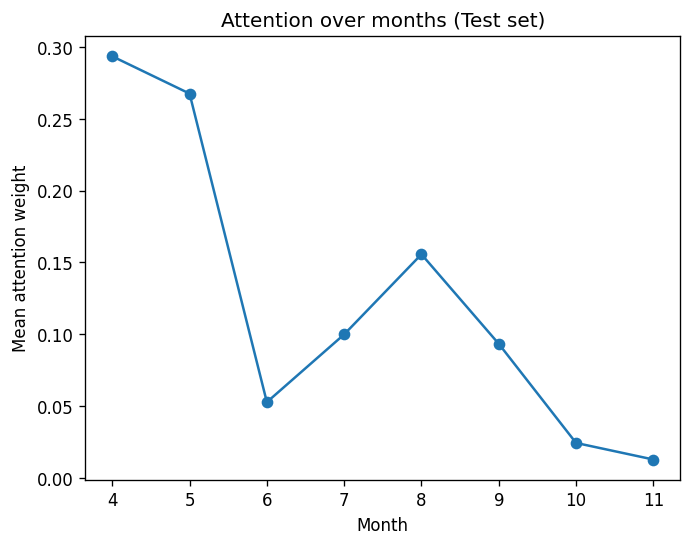

In [83]:

import matplotlib.pyplot as plt

yt, pt, attn = predict_all(model, test_loader, return_attn=True)

mean_attn = attn.mean(axis=0)
print("Mean attention:", mean_attn)

plt.figure()
plt.plot(timesteps, mean_attn, marker="o")
plt.xlabel("Month")
plt.ylabel("Mean attention weight")
plt.title("Attention over months (Test set)")
plt.show()


## Hyperparameter Tuning

In [149]:
import optuna

In [148]:
y_log_all = np.log1p(y_all.astype(np.float32))

In [116]:
# from torch.optim import AdamW

# def make_loaders(batch_size):
#     train_ds = PixelSequenceDataset(X_dyn_s[train_idx], X_static_s[train_idx], y_log_all[train_idx])
#     val_ds   = PixelSequenceDataset(X_dyn_s[val_idx],   X_static_s[val_idx],   y_log_all[val_idx])
#     test_ds  = PixelSequenceDataset(X_dyn_s[test_idx],  X_static_s[test_idx],  y_log_all[test_idx])
#     train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
#     val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
#     return train_loader, val_loader



In [150]:
def objective(trial):
    # --- Hyperparameters to tune ---
    proj_dim = trial.suggest_categorical("proj_dim", [32, 64, 96, 128])
    lstm_hidden = trial.suggest_categorical("lstm_hidden", [64, 96, 128, 160, 192, 256])
    lstm_layers = trial.suggest_int("lstm_layers", 1, 2)
    bidirectional = trial.suggest_categorical("bidirectional", [False, True])

    attn_dim = trial.suggest_categorical("attn_dim", [64, 96, 128, 192])
    static_hidden = trial.suggest_categorical("static_hidden", [64, 96, 128, 192])
    head_hidden = trial.suggest_categorical("head_hidden", [128, 192, 256, 384])

    dropout = trial.suggest_float("dropout", 0.05, 0.35)
    lr = trial.suggest_float("lr", 5e-4, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 5e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 384])

    max_epochs = 150
    patience = 6

    # loaders (use SCALED X and LOG y)
    train_ds = PixelSequenceDataset(X_dyn_s[train_idx], X_static_s[train_idx], y_log_all[train_idx])
    val_ds   = PixelSequenceDataset(X_dyn_s[val_idx],   X_static_s[val_idx],   y_log_all[val_idx])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    model = AttnLSTMRegressor(
        dyn_dim=X_dyn_s.shape[-1],
        static_dim=X_static_s.shape[-1],
        proj_dim=proj_dim,
        lstm_hidden=lstm_hidden,
        lstm_layers=lstm_layers,
        bidirectional=bidirectional,
        attn_dim=attn_dim,
        static_hidden=static_hidden,
        head_hidden=head_hidden,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    early = EarlyStopper(patience=patience)

    best_val = float("inf")

    for epoch in range(1, max_epochs + 1):
        train_one_epoch(model, train_loader, optimizer, device)

        y_pred_log, y_true_log = predict_all(model, val_loader, device)

        # tune in log space (stable)
        val_score = metrics_log(y_true_log, y_pred_log)["rmse_log"]

        # OR tune in original space:
        # val_score = metrics_original(y_true_log, y_pred_log)["rmse"]

        trial.report(val_score, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_score < best_val:
            best_val = val_score

        if early.step(val_score):
            break

    return best_val
# ----------------------------
# 11) Run Optuna
# ----------------------------
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=5),
)

N_TRIALS = 100  # increase when ready
print(f"Running Optuna for {N_TRIALS} trials...")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\nStudy summary")
print("Best value (val RMSE):", study.best_value)
print("Best params:", study.best_params)

# Print top few trials
top_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else 1e9)[:5]
for i, t in enumerate(top_trials, 1):
    print(f"\nTop {i}: val_rmse={t.value:.4f}, params={t.params}")
    print("  n_params:", t.user_attrs.get("n_params"), "best_epoch:", t.user_attrs.get("best_epoch"))


[I 2026-02-23 02:37:36,957] A new study created in memory with name: no-name-ea399222-a773-4300-b187-ae4fe676e85a


Running Optuna for 100 trials...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-02-23 02:37:54,601] Trial 0 finished with value: 0.4708082377910614 and parameters: {'proj_dim': 64, 'lstm_hidden': 160, 'lstm_layers': 1, 'bidirectional': False, 'attn_dim': 192, 'static_hidden': 192, 'head_hidden': 384, 'dropout': 0.28555278841790405, 'lr': 0.0007150664592404099, 'weight_decay': 7.982478599323911e-05, 'batch_size': 384}. Best is trial 0 with value: 0.4708082377910614.
[I 2026-02-23 02:38:22,262] Trial 1 finished with value: 0.4661533534526825 and parameters: {'proj_dim': 128, 'lstm_hidden': 64, 'lstm_layers': 1, 'bidirectional': True, 'attn_dim': 96, 'static_hidden': 128, 'head_hidden': 128, 'dropout': 0.07654775061557585, 'lr': 0.0007103531551331045, 'weight_decay': 1.46992232193749e-06, 'batch_size': 256}. Best is trial 1 with value: 0.4661533534526825.
[I 2026-02-23 02:38:27,383] Trial 2 finished with value: 0.4904748201370239 and parameters: {'proj_dim': 32, 'lstm_hidden': 160, 'lstm_layers': 1, 'bidirectional': False, 'attn_dim': 96, 'static_hidden': 96,

In [153]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW

# ---- helpers (use your existing ones if already defined) ----
def y_to_log(y):
    return np.log1p(y)

def log_to_y(y_log):
    return np.expm1(y_log)

def rmse(a, b):
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    return float(np.sqrt(np.mean((a - b) ** 2)))

def mae(a, b):
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    return float(np.mean(np.abs(a - b)))

# IMPORTANT: make sure you have log targets
# If your main target array is named y:
y_log_all = np.log1p(y.astype(np.float32))  # y is raw yield from build sequences

# If you already have make_loaders, ensure it uses y_log_all (not y)
def make_loaders(batch_size):
    train_ds = PixelSequenceDataset(X_dyn_s[train_idx], X_static_s[train_idx], y_log_all[train_idx])
    val_ds   = PixelSequenceDataset(X_dyn_s[val_idx],   X_static_s[val_idx],   y_log_all[val_idx])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader

# ----------------------------
# Retrain best model from Optuna
# ----------------------------
best = study.best_params

best_model = AttnLSTMRegressor(
    dyn_dim=X_dyn_s.shape[-1],
    static_dim=X_static_s.shape[-1],
    proj_dim=best["proj_dim"],
    lstm_hidden=best["lstm_hidden"],
    lstm_layers=best["lstm_layers"],
    bidirectional=best["bidirectional"],
    attn_dim=best["attn_dim"],
    static_hidden=best["static_hidden"],
    head_hidden=best["head_hidden"],
    dropout=best["dropout"],
).to(device)

optimizer = AdamW(best_model.parameters(), lr=best["lr"], weight_decay=best["weight_decay"])
train_loader, val_loader = make_loaders(best["batch_size"])
early = EarlyStopper(patience=6)

best_path = "best_attn_lstm_optuna.pt"
best_val = float("inf")

history = {
    "epoch": [],
    "train_mse_log": [],
    "val_rmse_log": [],
    "val_rmse_orig": [],
    "val_mae_orig": []
}

EPOCHS_FINAL = 40

for epoch in range(1, EPOCHS_FINAL + 1):
    tr_mse_log = train_one_epoch(best_model, train_loader, optimizer, device)

    # predict_all returns (pred_log, true_log)
    y_pred_log, y_true_log = predict_all(best_model, val_loader, device)

    # Log-space metric (matches training/tuning space)
    val_rmse_log = rmse(y_true_log, y_pred_log)

    # Original-space metrics for interpretation
    y_true_orig = log_to_y(y_true_log)
    y_pred_orig = log_to_y(y_pred_log)

    val_rmse_orig = rmse(y_true_orig, y_pred_orig)
    val_mae_orig  = mae(y_true_orig, y_pred_orig)

    history["epoch"].append(epoch)
    history["train_mse_log"].append(tr_mse_log)
    history["val_rmse_log"].append(val_rmse_log)
    history["val_rmse_orig"].append(val_rmse_orig)
    history["val_mae_orig"].append(val_mae_orig)

    print(
        f"Epoch {epoch:03d} | train_mse_log={tr_mse_log:.4f} | "
        f"val_rmse_log={val_rmse_log:.4f} | val_rmse={val_rmse_orig:.3f} | val_mae={val_mae_orig:.3f}"
    )

    # Choose ONE criterion for early stopping/checkpointing
    # I recommend val_rmse_log (stable)
    if val_rmse_log < best_val:
        best_val = val_rmse_log
        torch.save(best_model.state_dict(), best_path)

    if early.step(val_rmse_log):
        print("Early stopping.")
        break

print("Final best val RMSE (log space):", best_val)

# ----------------------------
# Evaluate on TEST
# ----------------------------
best_model.load_state_dict(torch.load(best_path, map_location=device))
best_model.eval()

test_ds = PixelSequenceDataset(X_dyn_s[test_idx], X_static_s[test_idx], y_log_all[test_idx])
test_loader = DataLoader(test_ds, batch_size=best["batch_size"], shuffle=False, num_workers=0)

y_pred_log_test, y_true_log_test = predict_all(best_model, test_loader, device)

y_true_test = log_to_y(y_true_log_test)
y_pred_test = log_to_y(y_pred_log_test)

test_rmse = rmse(y_true_test, y_pred_test)
test_mae  = mae(y_true_test, y_pred_test)

print("\nTest metrics (original units):")
print("  RMSE:", test_rmse)
print("  MAE :", test_mae)

Epoch 001 | train_mse_log=1.1369 | val_rmse_log=0.6290 | val_rmse=25.024 | val_mae=19.928
Epoch 002 | train_mse_log=0.1000 | val_rmse_log=0.4833 | val_rmse=16.649 | val_mae=13.645
Epoch 003 | train_mse_log=0.0864 | val_rmse_log=0.6099 | val_rmse=22.658 | val_mae=18.521
Epoch 004 | train_mse_log=0.0775 | val_rmse_log=0.4645 | val_rmse=16.447 | val_mae=13.639
Epoch 005 | train_mse_log=0.0794 | val_rmse_log=0.4563 | val_rmse=16.114 | val_mae=13.291
Epoch 006 | train_mse_log=0.0748 | val_rmse_log=0.6459 | val_rmse=25.967 | val_mae=21.438
Epoch 007 | train_mse_log=0.0730 | val_rmse_log=0.4579 | val_rmse=17.180 | val_mae=14.155
Epoch 008 | train_mse_log=0.0702 | val_rmse_log=0.4491 | val_rmse=15.948 | val_mae=13.166
Epoch 009 | train_mse_log=0.0640 | val_rmse_log=0.5009 | val_rmse=16.997 | val_mae=14.068
Epoch 010 | train_mse_log=0.0630 | val_rmse_log=0.4528 | val_rmse=15.624 | val_mae=12.831
Epoch 011 | train_mse_log=0.0643 | val_rmse_log=0.4700 | val_rmse=17.030 | val_mae=14.106
Epoch 012 

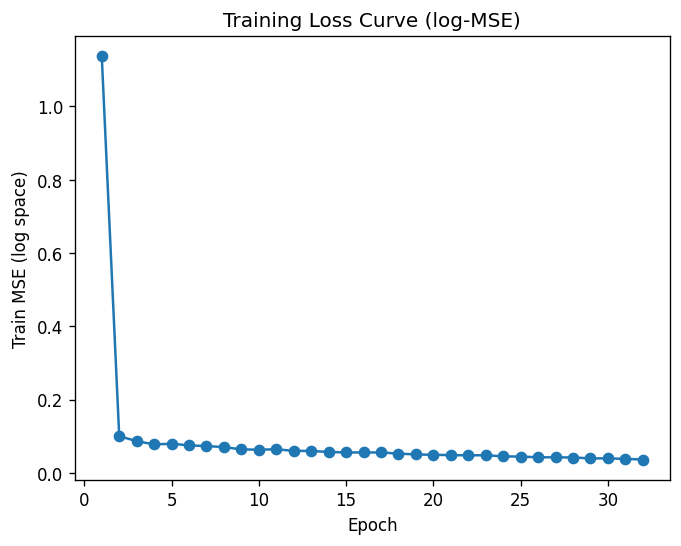

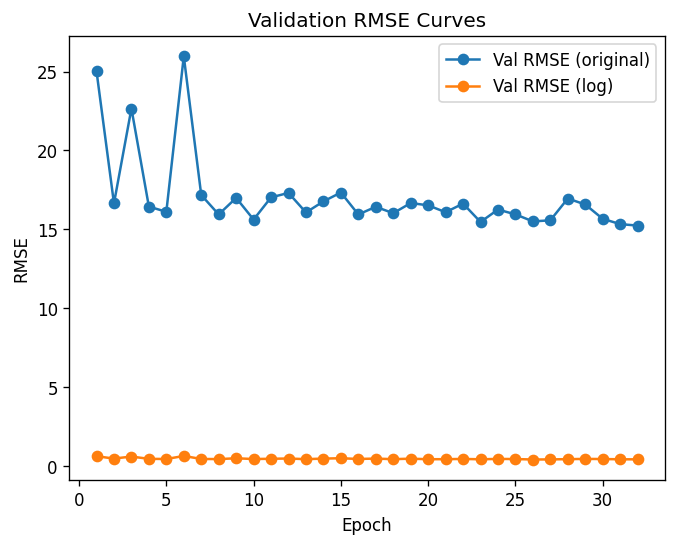

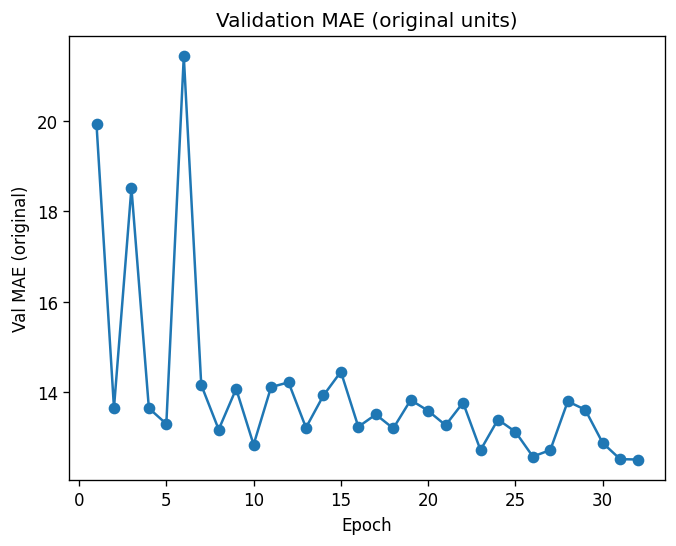


[VAL] Metrics (original units)
  rmse      : 15.5094
  mae       : 12.5664
  r2        : 0.3564
  pearson_r : 0.6242

[VAL] Flatline checks
  y_true std: 19.3326358795166 range: (5.756621360778809, 108.30574798583984)
  y_pred std: 10.035261154174805 range: (13.409506797790527, 70.8947525024414)


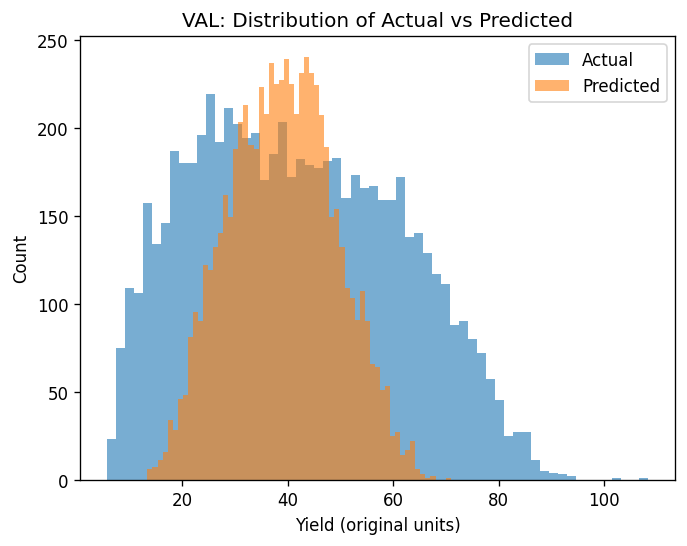

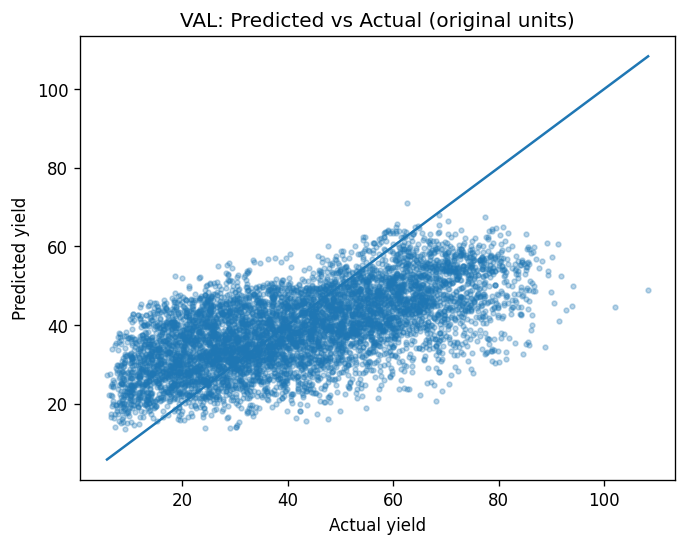

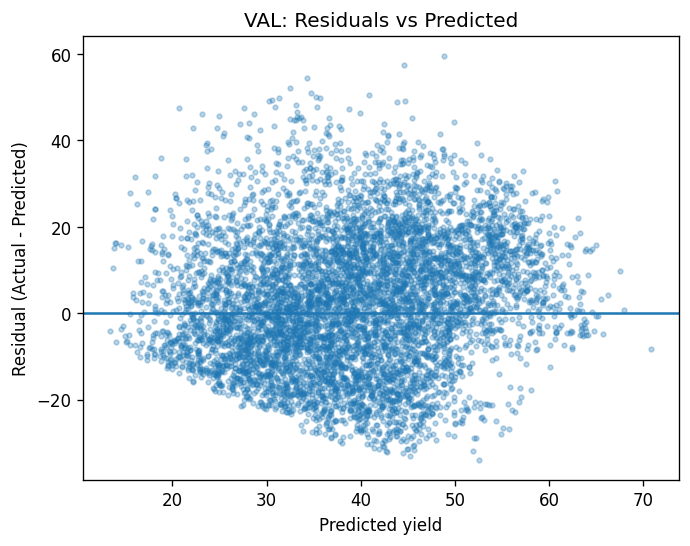

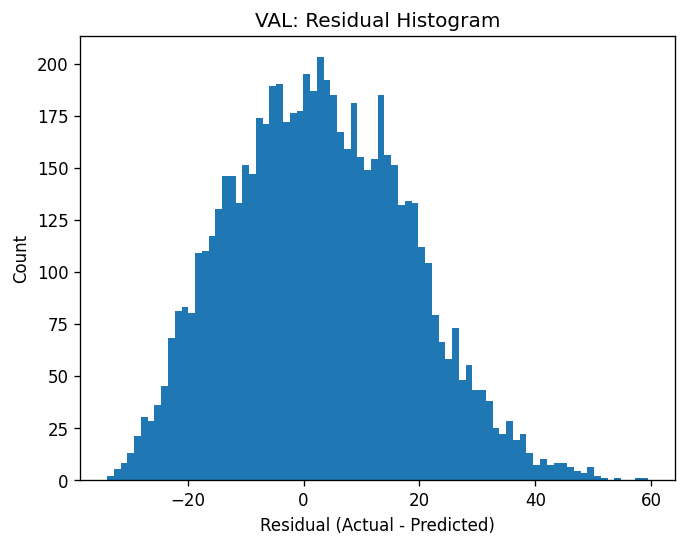

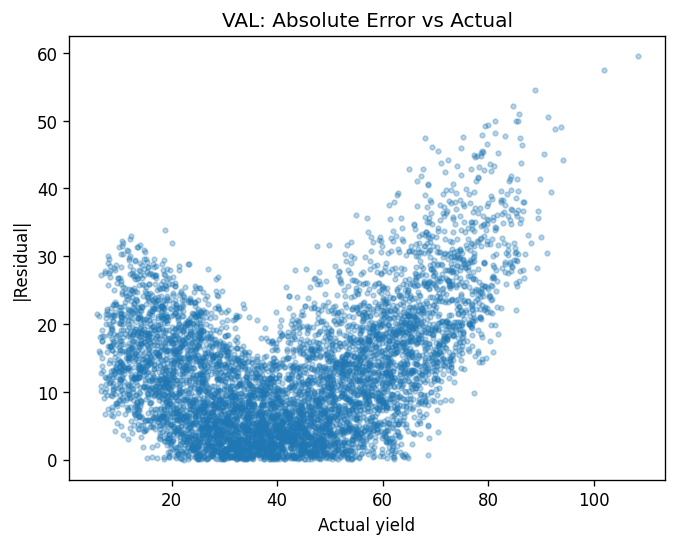

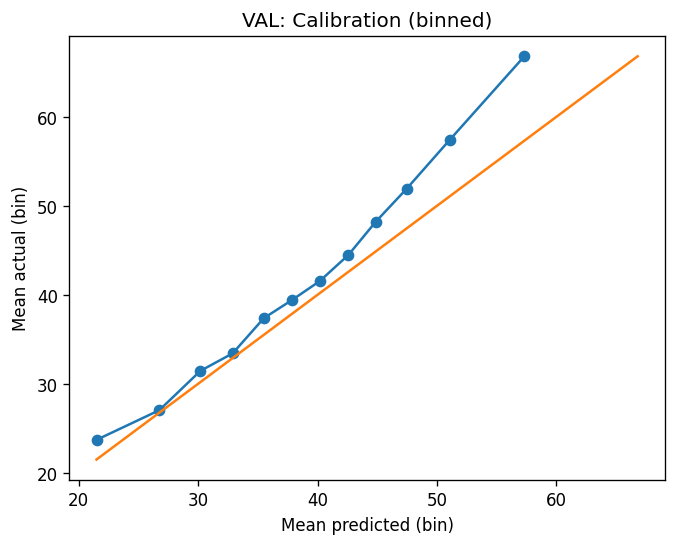


[TEST] Metrics (original units)
  rmse      : 14.2322
  mae       : 11.9781
  r2        : -0.3815
  pearson_r : 0.6419

[TEST] Flatline checks
  y_true std: 12.108609199523926 range: (10.200665473937988, 77.34148406982422)
  y_pred std: 10.991680145263672 range: (15.868284225463867, 85.97576904296875)


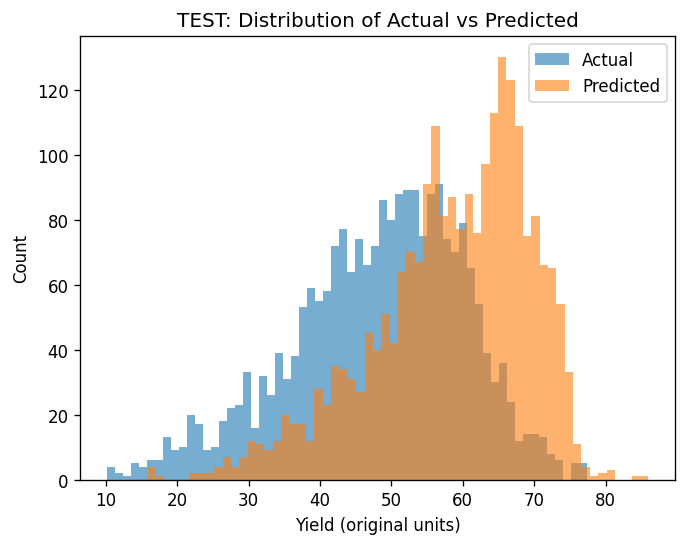

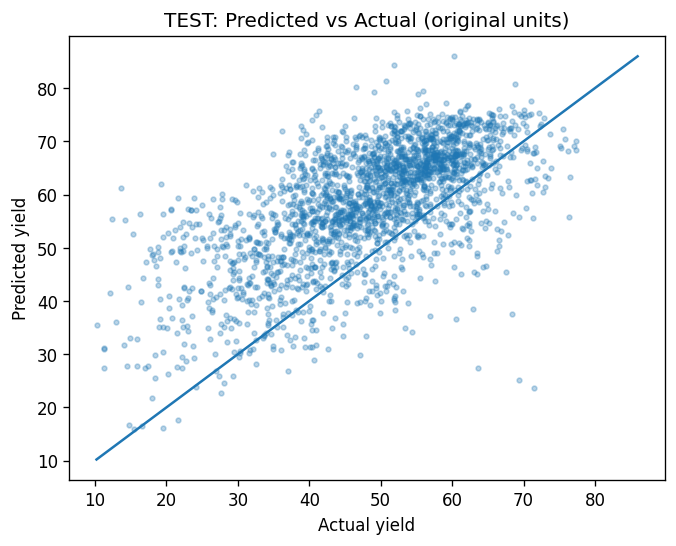

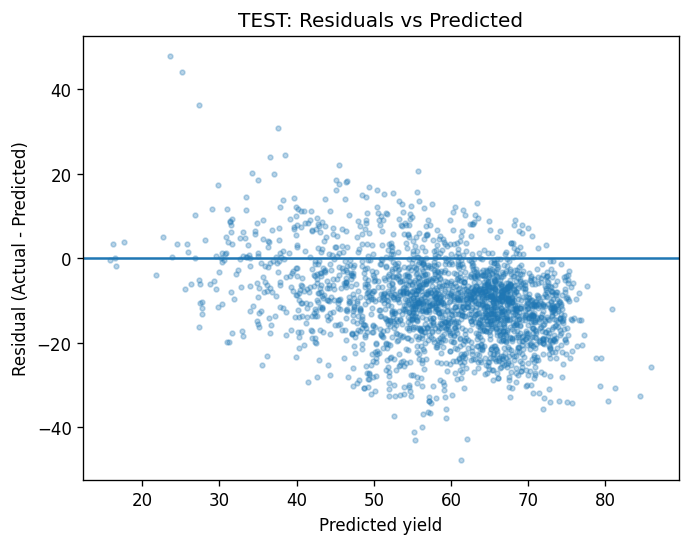

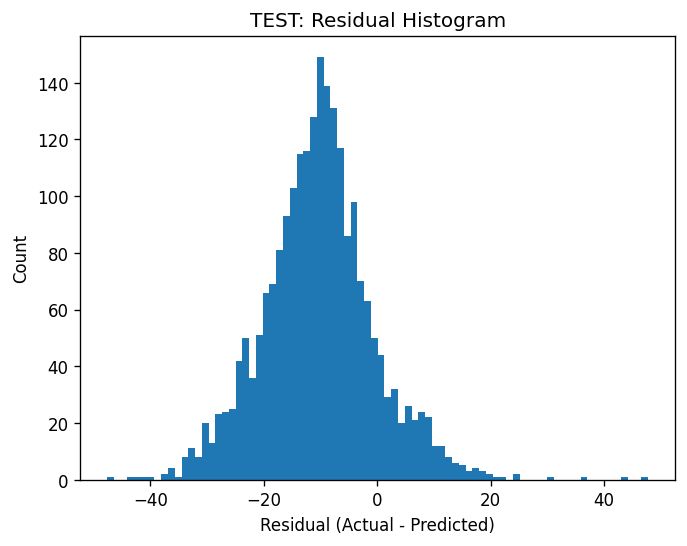

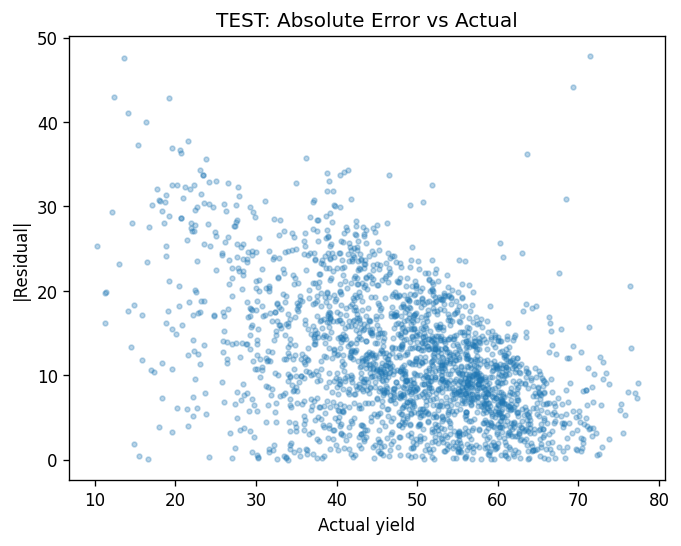

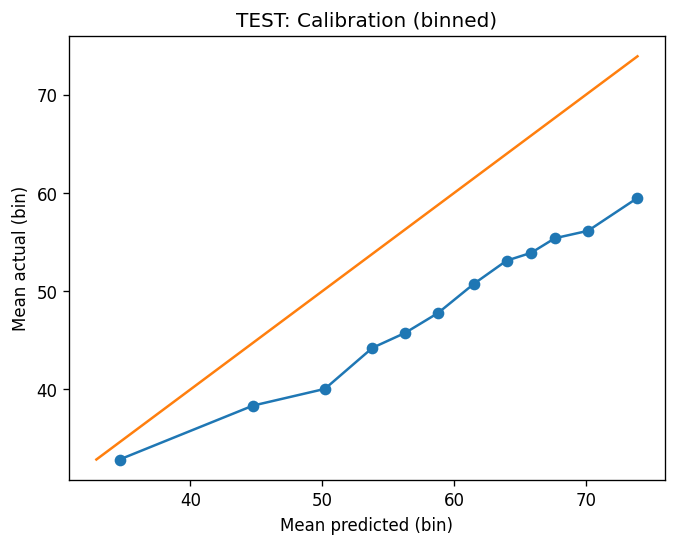

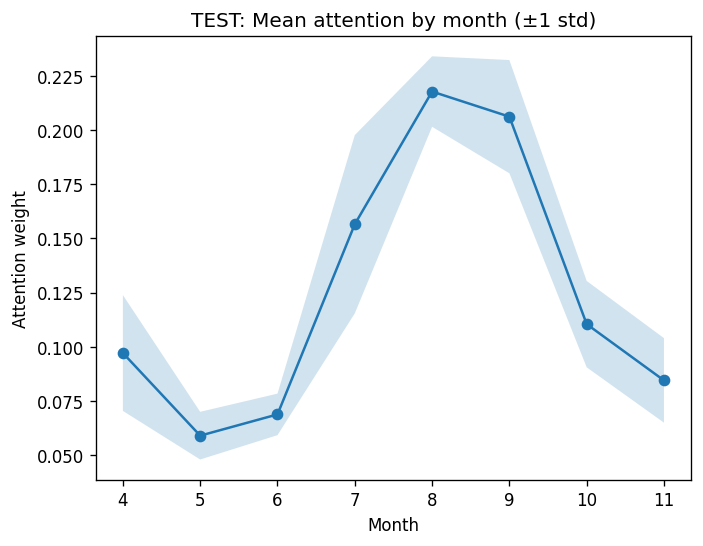

In [156]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Helpers: log <-> original
# -----------------------------
def y_to_log(y):
    return np.log1p(y)

def log_to_y(y_log):
    return np.expm1(y_log)

# -----------------------------
# Collect predictions utilities
# -----------------------------
@torch.no_grad()
def predict_all_with_optional_attn(model, loader, device, return_attn=False):
    model.eval()
    preds_log, ys_log = [], []
    attn_all = [] if return_attn else None

    for x_dyn, mask, x_static, y in loader:
        x_dyn = x_dyn.to(device)
        mask = mask.to(device)
        x_static = x_static.to(device)

        if return_attn:
            pred, attn = model(x_dyn, mask, x_static, return_attn=True)
            attn_all.append(attn.detach().cpu().numpy())
        else:
            pred = model(x_dyn, mask, x_static, return_attn=False)

        preds_log.append(pred.detach().cpu().numpy())
        ys_log.append(y.detach().cpu().numpy())

    y_pred_log = np.concatenate(preds_log).astype(np.float32)
    y_true_log = np.concatenate(ys_log).astype(np.float32)

    if return_attn:
        attn_all = np.concatenate(attn_all, axis=0)  # (N,T)
        return y_pred_log, y_true_log, attn_all

    return y_pred_log, y_true_log

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def mae(a, b):
    return float(np.mean(np.abs(a - b)))

def r2(a, b):
    ss_res = float(np.sum((a - b) ** 2))
    ss_tot = float(np.sum((a - np.mean(a)) ** 2))
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

def corr2(a, b):
    if np.std(a) == 0 or np.std(b) == 0:
        return float("nan")
    return (float(np.corrcoef(a, b)[0, 1])**2)

# -----------------------------
# 1) Plot training curves
# -----------------------------
def plot_training_curves(history):
    # history is a dict of lists as described above
    if history is None or len(history.get("epoch", [])) == 0:
        print("No history found. (You can still run the other plots.)")
        return

    epochs = history["epoch"]

    # Loss curve (log MSE)
    if "train_mse_log" in history:
        plt.figure()
        plt.plot(epochs, history["train_mse_log"], marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("Train MSE (log space)")
        plt.title("Training Loss Curve (log-MSE)")
        plt.show()

    # Validation RMSE curves
    if "val_rmse_orig" in history or "val_rmse_log" in history:
        plt.figure()
        if "val_rmse_orig" in history:
            plt.plot(epochs, history["val_rmse_orig"], marker="o", label="Val RMSE (original)")
        if "val_rmse_log" in history:
            plt.plot(epochs, history["val_rmse_log"], marker="o", label="Val RMSE (log)")
        plt.xlabel("Epoch")
        plt.ylabel("RMSE")
        plt.title("Validation RMSE Curves")
        plt.legend()
        plt.show()

    # MAE (optional)
    if "val_mae_orig" in history:
        plt.figure()
        plt.plot(epochs, history["val_mae_orig"], marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("Val MAE (original)")
        plt.title("Validation MAE (original units)")
        plt.show()

# -----------------------------
# 2) Flatline checks
# -----------------------------
def flatline_checks(y_true, y_pred, name="VAL"):
    pred_std = float(np.std(y_pred))
    true_std = float(np.std(y_true))
    pred_range = (float(np.min(y_pred)), float(np.max(y_pred)))
    true_range = (float(np.min(y_true)), float(np.max(y_true)))

    print(f"\n[{name}] Flatline checks")
    print("  y_true std:", true_std, "range:", true_range)
    print("  y_pred std:", pred_std, "range:", pred_range)

    # Heuristic warnings
    if pred_std < 1e-6:
        print("  ⚠️ WARNING: predictions are almost constant (flatline).")
    if pred_std < 0.1 * true_std:
        print("  ⚠️ WARNING: prediction variability is much smaller than true variability (underfitting).")

    # Plot distributions
    plt.figure()
    plt.hist(y_true, bins=60, alpha=0.6, label="Actual")
    plt.hist(y_pred, bins=60, alpha=0.6, label="Predicted")
    plt.title(f"{name}: Distribution of Actual vs Predicted")
    plt.xlabel("Yield (original units)")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

# -----------------------------
# 3) Predicted vs Actual scatter (original units)
# -----------------------------
def plot_pred_vs_actual(y_true, y_pred, name="VAL"):
    plt.figure()
    plt.scatter(y_true, y_pred, s=8, alpha=0.3)
    mn = float(min(y_true.min(), y_pred.min()))
    mx = float(max(y_true.max(), y_pred.max()))
    plt.plot([mn, mx], [mn, mx])  # 1:1 line
    plt.xlabel("Actual yield")
    plt.ylabel("Predicted yield")
    plt.title(f"{name}: Predicted vs Actual (original units)")
    plt.show()

# -----------------------------
# 4) Residual diagnostics
# -----------------------------
def plot_residuals(y_true, y_pred, name="VAL"):
    residual = y_true - y_pred

    # Residual vs predicted
    plt.figure()
    plt.scatter(y_pred, residual, s=8, alpha=0.3)
    plt.axhline(0)
    plt.xlabel("Predicted yield")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(f"{name}: Residuals vs Predicted")
    plt.show()

    # Residual histogram
    plt.figure()
    plt.hist(residual, bins=80)
    plt.xlabel("Residual (Actual - Predicted)")
    plt.ylabel("Count")
    plt.title(f"{name}: Residual Histogram")
    plt.show()

    # Absolute error vs actual (heteroscedasticity)
    abs_err = np.abs(residual)
    plt.figure()
    plt.scatter(y_true, abs_err, s=8, alpha=0.3)
    plt.xlabel("Actual yield")
    plt.ylabel("|Residual|")
    plt.title(f"{name}: Absolute Error vs Actual")
    plt.show()

# -----------------------------
# 5) Calibration curve (binned)
# -----------------------------
def plot_calibration(y_true, y_pred, bins=10, name="VAL"):
    # bin by predicted
    q = np.linspace(0, 1, bins + 1)
    edges = np.quantile(y_pred, q)
    # handle duplicates edges
    edges = np.unique(edges)
    if len(edges) < 3:
        print("Calibration skipped: not enough unique prediction values.")
        return

    bin_ids = np.digitize(y_pred, edges[1:-1], right=True)
    x, y = [], []
    for b in range(bin_ids.min(), bin_ids.max() + 1):
        mask = bin_ids == b
        if mask.sum() < 20:
            continue
        x.append(float(np.mean(y_pred[mask])))
        y.append(float(np.mean(y_true[mask])))

    if len(x) < 2:
        print("Calibration skipped: too few bins with data.")
        return

    plt.figure()
    plt.plot(x, y, marker="o")
    mn = float(min(min(x), min(y)))
    mx = float(max(max(x), max(y)))
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Mean predicted (bin)")
    plt.ylabel("Mean actual (bin)")
    plt.title(f"{name}: Calibration (binned)")
    plt.show()

# -----------------------------
# 6) Metrics printout
# -----------------------------
def print_metrics(y_true, y_pred, name="VAL"):
    m = {
        "rmse": rmse(y_true, y_pred),
        "mae": mae(y_true, y_pred),
        "r2": r2(y_true, y_pred),
        "pearson_r": pearsonr(y_true, y_pred),
    }
    print(f"\n[{name}] Metrics (original units)")
    for k, v in m.items():
        print(f"  {k:10s}: {v:.4f}")
    return m

# -----------------------------
# 7) Attention diagnostics (if available)
# -----------------------------
def plot_attention(attn, season_months, name="TEST"):
    # attn: (N,T)
    mean_attn = attn.mean(axis=0)
    std_attn = attn.std(axis=0)

    plt.figure()
    plt.plot(season_months, mean_attn, marker="o")
    # std band
    plt.fill_between(season_months, mean_attn - std_attn, mean_attn + std_attn, alpha=0.2)
    plt.xlabel("Month")
    plt.ylabel("Attention weight")
    plt.title(f"{name}: Mean attention by month (±1 std)")
    plt.show()

# ============================================================
# RUN ALL DIAGNOSTICS (VAL + TEST)
# ============================================================

# 1) Training curves (if you saved them)
plot_training_curves(history)   # uncomment if you have history dict

# 2) Validation predictions
y_pred_log_val, y_true_log_val = predict_all_with_optional_attn(best_model, val_loader, device, return_attn=False)
y_pred_val = log_to_y(y_pred_log_val)
y_true_val = log_to_y(y_true_log_val)

print_metrics(y_true_val, y_pred_val, name="VAL")
flatline_checks(y_true_val, y_pred_val, name="VAL")
plot_pred_vs_actual(y_true_val, y_pred_val, name="VAL")
plot_residuals(y_true_val, y_pred_val, name="VAL")
plot_calibration(y_true_val, y_pred_val, bins=12, name="VAL")

# 3) Test predictions
y_pred_log_test, y_true_log_test, attn_test = predict_all_with_optional_attn(best_model, test_loader, device, return_attn=True)
y_pred_test = log_to_y(y_pred_log_test)
y_true_test = log_to_y(y_true_log_test)

print_metrics(y_true_test, y_pred_test, name="TEST")
flatline_checks(y_true_test, y_pred_test, name="TEST")
plot_pred_vs_actual(y_true_test, y_pred_test, name="TEST")
plot_residuals(y_true_test, y_pred_test, name="TEST")
plot_calibration(y_true_test, y_pred_test, bins=12, name="TEST")

# 4) Attention plot
plot_attention(attn_test, SEASON_MONTHS, name="TEST")

In [157]:
def flatline_sorted_curve(y_true, y_pred, title="Flatline Check"):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    # keep finite only
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[m]
    y_pred = y_pred[m]

    yt = np.sort(y_true)
    yp = np.sort(y_pred)

    plt.figure()
    plt.plot(yt, label="Actual (sorted)")
    plt.plot(yp, label="Pred (sorted)")
    plt.xlabel("Sample (sorted)")
    plt.ylabel("Yield")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

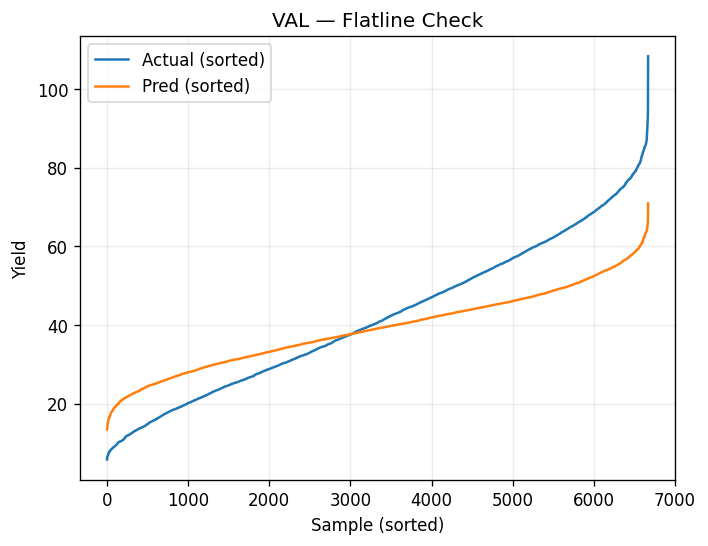

In [158]:
flatline_sorted_curve(y_true_val, y_pred_val, title="VAL — Flatline Check")

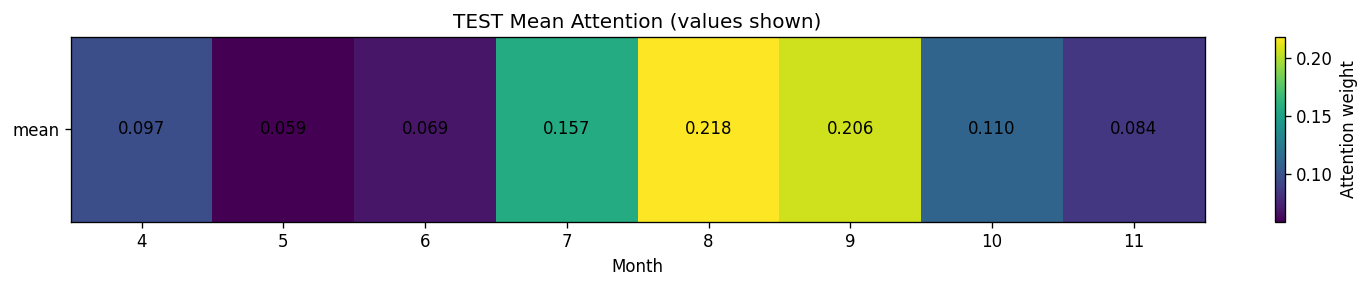

In [162]:
def plot_mean_attention_with_values(attn, months, title="Mean attention (with values)"):
    A = np.asarray(attn, dtype=np.float32)
    mean_attn = A.mean(axis=0, keepdims=True)  # (1,T)

    fig, ax = plt.subplots(figsize=(1.2*len(months) + 3, 2.5))
    im = ax.imshow(mean_attn, aspect="auto")

    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_yticks([0])
    ax.set_yticklabels(["mean"])

    ax.set_xticks(np.arange(len(months)))
    ax.set_xticklabels(months)

    plt.colorbar(im, ax=ax, label="Attention weight")

    # annotate all cells
    for j in range(mean_attn.shape[1]):
        ax.text(j, 0, f"{mean_attn[0, j]:.3f}", ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_mean_attention_with_values(attn_test, SEASON_MONTHS, title="TEST Mean Attention (values shown)")
# plot_mean_attention_with_values(attn_val, SEASON_MONTHS, title="TEST Mean Attention (values shown)")